#  Problema: Clasificación del método de detección (detection_method)
### Dataset: Kaggle NASA Exoplanets (CSV en src/data_sample/)

## Paso 1: Entendimiento del problema

### Importo librerías

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
print("Entorno listo")

Entorno listo


### Rutas (mínimas)

In [ ]:
ROOT = Path.cwd()

SAMPLE_DIR = ROOT / "src" / "data_sample"
IMG_DIR = ROOT / "src" / "img"
MODELS_DIR = ROOT / "src" / "models"

IMG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("SAMPLE_DIR:", SAMPLE_DIR)
print("IMG_DIR:", IMG_DIR)
print("MODELS_DIR:", MODELS_DIR)

### Cargamos el Dataset

In [8]:
csvs = sorted(SAMPLE_DIR.glob("*.csv"))
print("CSVs encontrados:", [c.name for c in csvs])

if not csvs:
    raise FileNotFoundError("No hay CSV en src/data_sample/. Mete el dataset ahí.")

DATA_PATH = csvs[0]  # si hay varios, cambia aquí
df = pd.read_csv(DATA_PATH)

print("✅ Dataset cargado:", DATA_PATH.name)
print("Shape:", df.shape)
df.head()

CSVs encontrados: ['cleaned_5250.csv']
✅ Dataset cargado: cleaned_5250.csv
Shape: (5250, 13)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


### Auditoría rápida

In [ ]:
display(df.describe(include="all").T.head(30))

missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("Top missing (%):")
display(missing.head(20))
## Observamos la presencia de valores faltantes en varias variables

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,5250,5250,11 Comae Berenices b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance,5233.0,NaN,NaN,NaN,2167.168737,3245.522087,4.0,389.0,1371.0,2779.0,27727.0
stellar_magnitude,5089.0,NaN,NaN,NaN,12.683738,3.107571,0.872,10.939,13.543,15.021,44.61
planet_type,5250,5,Neptune-like,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discovery_year,5250.0,NaN,NaN,NaN,2015.73219,4.307336,1992.0,2014.0,2016.0,2018.0,2023.0
mass_multiplier,5227.0,NaN,NaN,NaN,6.434812,12.972727,0.02,1.804,4.17014,8.0,752.0
mass_wrt,5227,2,Earth,3586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
radius_multiplier,5233.0,NaN,NaN,NaN,1.015121,0.603479,0.2,0.325,1.12,1.41,6.9
radius_wrt,5233,2,Jupiter,3310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orbital_radius,4961.0,NaN,NaN,NaN,6.962942,138.6736,0.0044,0.053,0.1028,0.286,7506.0


Top missing (%):


orbital_radius       5.50
stellar_magnitude    3.07
mass_multiplier      0.44
mass_wrt             0.44
distance             0.32
radius_multiplier    0.32
radius_wrt           0.32
name                 0.00
planet_type          0.00
discovery_year       0.00
orbital_period       0.00
eccentricity         0.00
detection_method     0.00
dtype: float64

### Limpieza de datos

In [10]:
df = df.copy()
df.replace(r"^\s*$", np.nan, regex=True, inplace=True)

n0 = len(df)
df.drop_duplicates(inplace=True)
print("Duplicados eliminados:", n0 - len(df))

Duplicados eliminados: 0


### Definimos como target "detection_method"

In [ ]:

TARGET_COL = None
candidates = ["detection_method", "discoverymethod", "discovery_method", "method", "pl_discmethod"]

cols_lower = {c.lower(): c for c in df.columns}
for c in candidates:
    if c in cols_lower:
        TARGET_COL = cols_lower[c]
        break

if TARGET_COL is None:
    for c in df.columns:
        if "method" in c.lower():
            TARGET_COL = c
            break

if TARGET_COL is None:
    raise ValueError("No encontramos columna de método. Imprime df.columns y ajusta TARGET_COL manualmente.")

print(" TARGET_COL:", TARGET_COL)
display(df[TARGET_COL].value_counts(dropna=False).head(20))

🎯 TARGET_COL: detection_method


Transit                          3945
Radial Velocity                  1027
Gravitational Microlensing        154
Direct Imaging                     62
Transit Timing Variations          24
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       7
Astrometry                          2
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: detection_method, dtype: int64

### Definimos X/y + EDA dirigido al modelado

Clases tras filtrar rarezas (>=25 ejemplos): 4


Transit                       3945
Radial Velocity               1027
Gravitational Microlensing     154
Direct Imaging                  62
Name: detection_method, dtype: int64

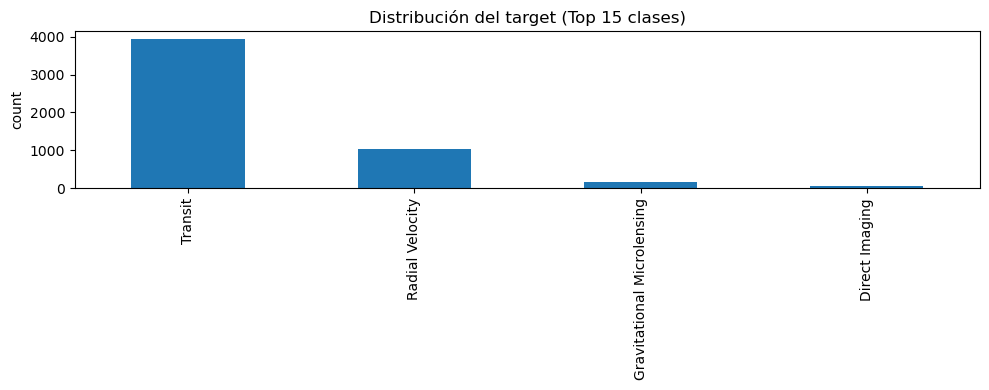

In [ ]:
SAVE_FIGS = True
def savefig(name: str):
    if SAVE_FIGS:
        plt.savefig(IMG_DIR / name, dpi=150, bbox_inches="tight")

y = df[TARGET_COL].astype(str).str.strip()
X = df.drop(columns=[TARGET_COL])

# Quitamos NaN del target (no se puede entrenar sin etiqueta)
mask = ~(df[TARGET_COL].isna())
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# nos quedamos con las clases más frecuentes 
min_class = 25
vc = y.value_counts()
keep_classes = vc[vc >= min_class].index
y = y.where(y.isin(keep_classes), other=np.nan)
keep = ~y.isna()
X, y = X.loc[keep], y.loc[keep]

print("Clases tras filtrar rarezas (>=25 ejemplos):", y.nunique())
display(y.value_counts().head(15))

# Plot del target
plt.figure(figsize=(10,4))
y.value_counts().head(15).plot(kind="bar")
plt.title("Distribución del target (Top 15 clases)")
plt.ylabel("count")
plt.tight_layout()
savefig("target_detection_method.png")
plt.show()

In [ ]:
# vemos la distribución relativa del target
plt.figure(figsize=(12,5))
target_counts = y.value_counts()
(target_counts / len(y)).plot(kind="bar")

plt.title("Distribución relativa del target")
plt.ylabel("Proporción")
plt.xticks(rotation=45)
plt.tight_layout()
savefig("target_distribution_relative.png")
plt.show()

print("Número de clases:", y.nunique())
print("Clase mayoritaria (%):", round(target_counts.max()/len(y)*100, 2))

# como el target presenta cierto desbalanceo, utilizaremos el F1-macro

In [ ]:
# Heatmap de NAs
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.tight_layout()
savefig("missing_heatmap.png")
plt.show()

Numéricas: 8 | Categóricas/otras: 4


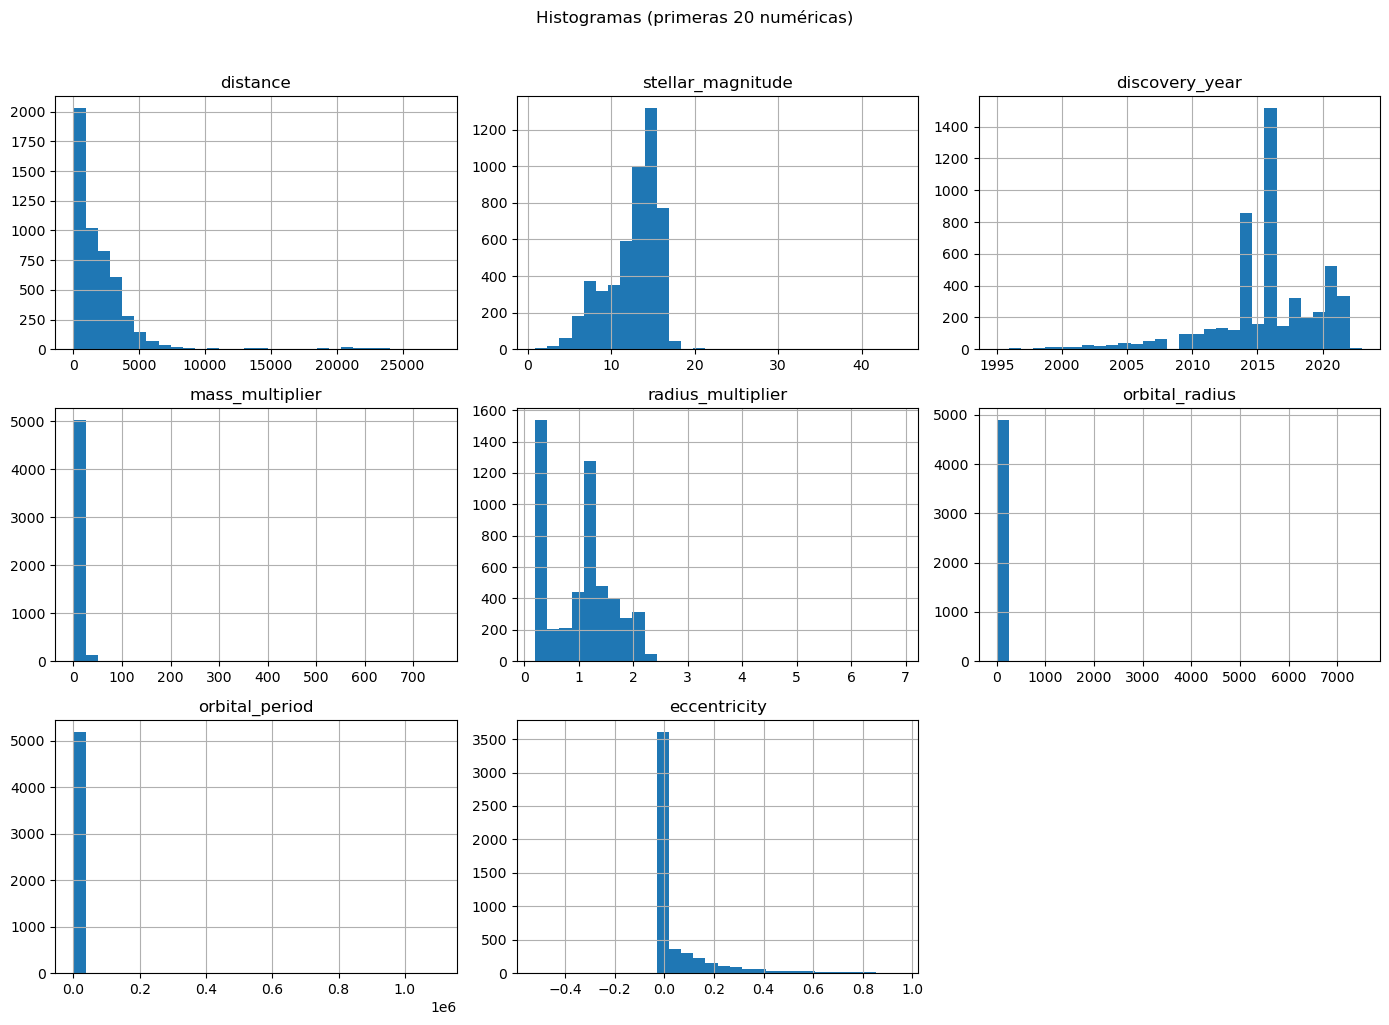

In [ ]:
# # Separación de variables numéricas/categóricas
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print("Numéricas:", len(num_cols), "| Categóricas/otras:", len(cat_cols))

# Histogramas numéricas 
if len(num_cols) > 0:
    cols_to_plot = num_cols[:20]
    X[cols_to_plot].hist(figsize=(14,10), bins=30)
    plt.suptitle("Histogramas (primeras 20 numéricas)", y=1.02)
    plt.tight_layout()
    savefig("hist_numericas.png")
    plt.show()

In [ ]:
# Correlación numérica

if len(num_cols) > 1:
    corr = X[num_cols].corr()

    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación")
    plt.tight_layout()
    savefig("correlation_matrix.png")
    plt.show()


In [ ]:
# Cardinalidad categórica: evaluamos la cardinalidad para justificar el uso de OneHotEncoder

cat_cardinality = (
    X[cat_cols]
    .nunique()
    .sort_values(ascending=False)
    .to_frame(name="n_unique")
)

display(cat_cardinality.head(15))

In [ ]:
# Boxplots vs target (top numéricas)

top_num = num_cols[:5]

for col in top_num:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=y, y=X[col])
    plt.title(f"{col} vs target")
    plt.xticks(rotation=45)
    plt.tight_layout()
    savefig(f"boxplot_{col}_vs_target.png")
    plt.show()

### Split train/test (estratificado)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (4150, 12) | Test: (1038, 12)


### Preprocesado + Feature Engineering (pipeline)

In [16]:
# numéricas: imputación median + escalado
# categóricas: imputación moda + one-hot
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("✅ Preprocessor creado")

✅ Preprocessor creado


### Baseline + comparativa de modelos (CV)
##### Métrica: F1 macro (buena con desbalanceo)

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = {"f1_macro": "f1_macro", "accuracy": "accuracy"}

models = {
    "Dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=3000),
    "RF": RandomForestClassifier(random_state=RANDOM_SEED),
    "GBC": GradientBoostingClassifier(random_state=RANDOM_SEED),
}

results = []
pipes = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipes[name] = pipe

    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "model": name,
        "f1_macro": float(np.mean(cv_res["test_f1_macro"])),
        "f1_macro_std": float(np.std(cv_res["test_f1_macro"])),
        "accuracy": float(np.mean(cv_res["test_accuracy"])),
        "accuracy_std": float(np.std(cv_res["test_accuracy"])),
    })

leaderboard = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
print("📊 Leaderboard CV:")
display(leaderboard)
best_name = leaderboard.iloc[0]["model"]
print("🏆 Mejor baseline:", best_name)

📊 Leaderboard CV:


,model,f1_macro,f1_macro_std,accuracy,accuracy_std
2,RF,0.925058,0.034153,0.969398,0.005474
3,GBC,0.911298,0.016525,0.966506,0.005020
1,LogReg,0.837387,0.062753,0.939277,0.011292
0,Dummy_most_frequent,0.215987,0.000078,0.760482,0.000482


🏆 Mejor baseline: RF


### Hacemos Tuning del mejor modelo real

In [18]:
if best_name == "Dummy_most_frequent":
    best_name = "LogReg"

best_pipe = pipes[best_name]
print("🔧 Modelo a tunear:", best_name)

if best_name == "LogReg":
    param_dist = {"model__C": np.logspace(-3, 2, 30)}
elif best_name == "RF":
    param_dist = {
        "model__n_estimators": [300, 600, 900],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    }
else:  # GBC
    param_dist = {
        "model__n_estimators": [150, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4]
    }

search = RandomizedSearchCV(
    estimator=best_pipe,
    param_distributions=param_dist,
    n_iter=25,
    cv=cv,
    scoring="f1_macro",
    refit=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("Mejor F1_macro CV:", search.best_score_)
print("Mejores params:", search.best_params_)

🔧 Modelo a tunear: RF
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Mejor F1_macro CV: 0.9325196675950178
Mejores params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}


### Evaluación final en TEST

=== Classification report (TEST) ===
                            precision    recall  f1-score   support

            Direct Imaging       1.00      0.83      0.91        12
Gravitational Microlensing       1.00      1.00      1.00        31
           Radial Velocity       0.96      0.94      0.95       206
                   Transit       0.98      0.99      0.99       789

                  accuracy                           0.98      1038
                 macro avg       0.98      0.94      0.96      1038
              weighted avg       0.98      0.98      0.98      1038



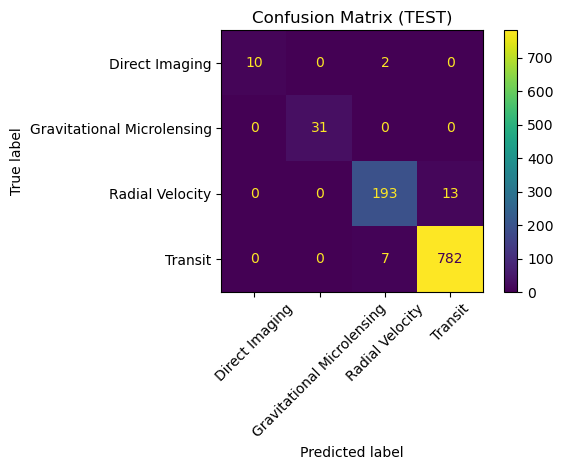

In [19]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("=== Classification report (TEST) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (TEST)")
plt.tight_layout()
savefig("confusion_matrix_test.png")
plt.show()

### Guardado del modelo + model card (requisito)

In [20]:
MODEL_PATH = MODELS_DIR / "best_model_detection_method.joblib"
joblib.dump(best_model, MODEL_PATH)
print("Modelo guardado en:", MODEL_PATH)

model_card = {
    "dataset_file": DATA_PATH.name,
    "target_col": TARGET_COL,
    "problem_type": "classification",
    "classes_kept_min_support": 25,
    "best_model": best_name,
    "best_params": search.best_params_,
    "best_cv_f1_macro": float(search.best_score_),
    "random_seed": RANDOM_SEED,
    "train_shape": [int(X_train.shape[0]), int(X_train.shape[1])],
    "test_shape": [int(X_test.shape[0]), int(X_test.shape[1])]
}

with open(MODELS_DIR / "model_card.json", "w", encoding="utf-8") as f:
    json.dump(model_card, f, ensure_ascii=False, indent=2)

print("🧾 model_card.json guardado en", MODELS_DIR)
model_card

Modelo guardado en: c:\Users\gerar\Documents\Bootcamp DS\Carmen-Bootcamp_DS\ML_NASA-Exoplanets_Detection_Method\src\models\best_model_detection_method.joblib
🧾 model_card.json guardado en c:\Users\gerar\Documents\Bootcamp DS\Carmen-Bootcamp_DS\ML_NASA-Exoplanets_Detection_Method\src\models


{'dataset_file': 'cleaned_5250.csv',
 'target_col': 'detection_method',
 'problem_type': 'classification',
 'classes_kept_min_support': 25,
 'best_model': 'RF',
 'best_params': {'model__n_estimators': 300,
  'model__min_samples_split': 2,
  'model__min_samples_leaf': 1,
  'model__max_depth': None},
 'best_cv_f1_macro': 0.9325196675950178,
 'random_seed': 42,
 'train_shape': [4150, 12],
 'test_shape': [1038, 12]}